In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, lasso_path
from sklearn.metrics import r2_score, root_mean_squared_error

In [ ]:
df = pd.read_excel('../data_manufacturing.xlsx')
y = df['Dissolution'].values
X_df = df.drop(columns=['Dissolution'])

# Get indices of the categorical columns
string_col_indices = [i for i, c in enumerate(X_df.columns)
                      if X_df[c].dtype == object or str(X_df[c].dtype) == 'str']

# One-Hot encode categoricals
pre = ColumnTransformer(
    transformers=[('ohe', OneHotEncoder(drop='first', sparse_output=False),
                   string_col_indices)],
    remainder='passthrough'
)
X = pre.fit_transform(X_df)
feature_names = [n.replace('ohe__', '').replace('remainder__', '')
                 for n in pre.get_feature_names_out()]
print('Design matrix:', X.shape)

Design matrix: (90, 19)


In [ ]:
# Scale features for Lasso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Lasso with 5-fold CV to find optimal alpha
lasso_cv = LassoCV(cv=5, random_state=0, max_iter=100000).fit(X_scaled, y)
alpha_opt = lasso_cv.alpha_
print(f'Optimal alpha (5-fold CV): {alpha_opt:.5f}')
print(f'log10(alpha) = {np.log10(alpha_opt):.3f}')

Optimal alpha (5-fold CV): 0.04821
log10(alpha) = -1.317


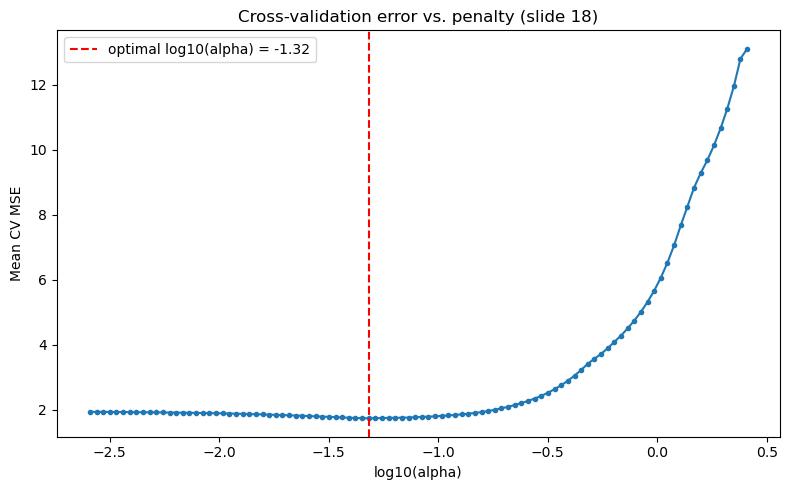

In [ ]:
# Plot CV MSE vs. log10(alpha)
mse_path = lasso_cv.mse_path_.mean(axis=1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.log10(lasso_cv.alphas_), mse_path, marker='.')
ax.axvline(np.log10(alpha_opt), color='red', linestyle='--',
           label=f'optimal log10(alpha) = {np.log10(alpha_opt):.2f}')
ax.set_xlabel('log10(alpha)'); ax.set_ylabel('Mean CV MSE')
ax.set_title('Cross-validation error vs. penalty (slide 18)')
ax.legend(); plt.tight_layout(); plt.show()

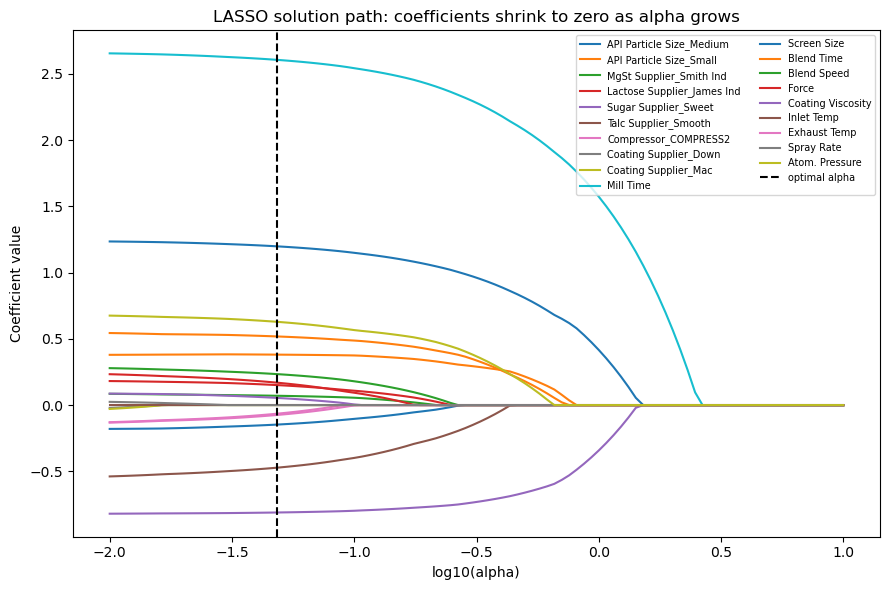

In [ ]:
# Plot Lasso solution path
alphas_path, coefs_path, _ = lasso_path(X_scaled, y, alphas=np.logspace(-2, 1, 100))

fig, ax = plt.subplots(figsize=(9, 6))
for i in range(coefs_path.shape[0]):
    ax.plot(np.log10(alphas_path), coefs_path[i], label=feature_names[i])
ax.axvline(np.log10(alpha_opt), color='k', linestyle='--', label='optimal alpha')
ax.set_xlabel('log10(alpha)'); ax.set_ylabel('Coefficient value')
ax.set_title('LASSO solution path: coefficients shrink to zero as alpha grows')
ax.legend(fontsize=7, ncol=2, loc='upper right'); plt.tight_layout(); plt.show()

In [ ]:
# Fit Lasso with optimal alpha and evaluate performance
lasso = Lasso(alpha=alpha_opt, max_iter=100000).fit(X_scaled, y)
y_hat = lasso.predict(X_scaled)

r2_lasso   = r2_score(y, y_hat)
rmse_lasso = root_mean_squared_error(y, y_hat)
n_nonzero  = np.sum(lasso.coef_ != 0)

print(f'R^2  = {r2_lasso:.4f}')
print(f'RMSE = {rmse_lasso:.4f}')
print(f'Non-zero coefficients: {n_nonzero} / {len(feature_names)}')

R^2  = 0.9166
RMSE = 1.0287
Non-zero coefficients: 15 / 19


In [ ]:
# List eliminated features (coef = 0) and retained features with their coefficients
eliminated = [f for f, c in zip(feature_names, lasso.coef_) if c == 0]
print('Eliminated features (coef = 0):')
for f in eliminated:
    print('  -', f)

print('\nRetained features and coefficients:')
for f, c in sorted(zip(feature_names, lasso.coef_), key=lambda t: -abs(t[1])):
    if c != 0:
        print(f'  {f:<28s} {c:+.4f}')

Eliminated features (coef = 0):
  - Coating Supplier_Down
  - Coating Supplier_Mac
  - Inlet Temp
  - Spray Rate

Retained features and coefficients:
  Mill Time                    +2.6062
  Screen Size                  +1.1984
  Sugar Supplier_Sweet         -0.8109
  Atom. Pressure               +0.6286
  API Particle Size_Small      +0.5181
  Talc Supplier_Smooth         -0.4729
  Blend Time                   +0.3807
  MgSt Supplier_Smith Ind      +0.2338
  Force                        +0.1692
  Lactose Supplier_James Ind   +0.1510
  API Particle Size_Medium     -0.1474
  Exhaust Temp                 -0.0750
  Blend Speed                  +0.0702
  Compressor_COMPRESS2         -0.0654
  Coating Viscosity            +0.0541


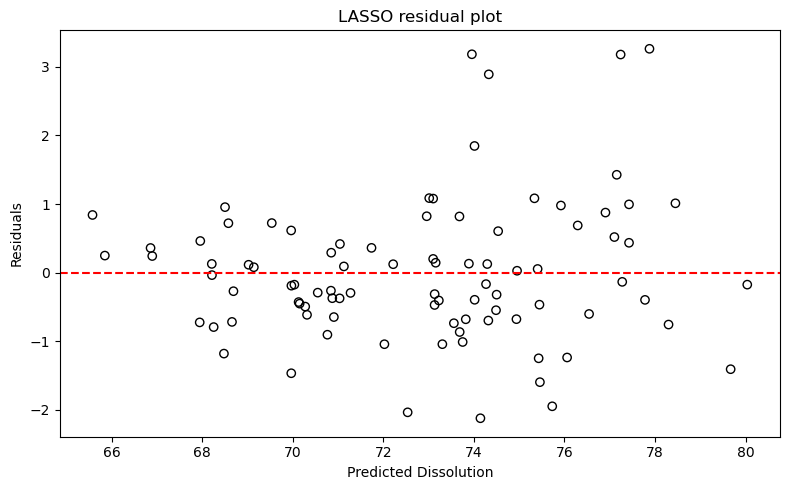

In [ ]:
# Plot residuals vs. predicted values to check for patterns
residuals = y - y_hat
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_hat, residuals, edgecolor='k', facecolor='none')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Predicted Dissolution'); ax.set_ylabel('Residuals')
ax.set_title('LASSO residual plot'); plt.tight_layout(); plt.show()

In [ ]:
# Fit OLS for comparison
ols = LinearRegression().fit(X, y)
y_ols = ols.predict(X)
r2_ols   = r2_score(y, y_ols)
rmse_ols = root_mean_squared_error(y, y_ols)

print(f'{"Model":<10}{"R^2":>10}{"RMSE":>10}{"# features":>14}')
print(f'{"OLS":<10}{r2_ols:>10.4f}{rmse_ols:>10.4f}{len(feature_names):>14}')
print(f'{"LASSO":<10}{r2_lasso:>10.4f}{rmse_lasso:>10.4f}{int(n_nonzero):>14}')

Model            R^2      RMSE    # features
OLS           0.9196    1.0103            19
LASSO         0.9166    1.0287            15
